In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.decomposition import PCA

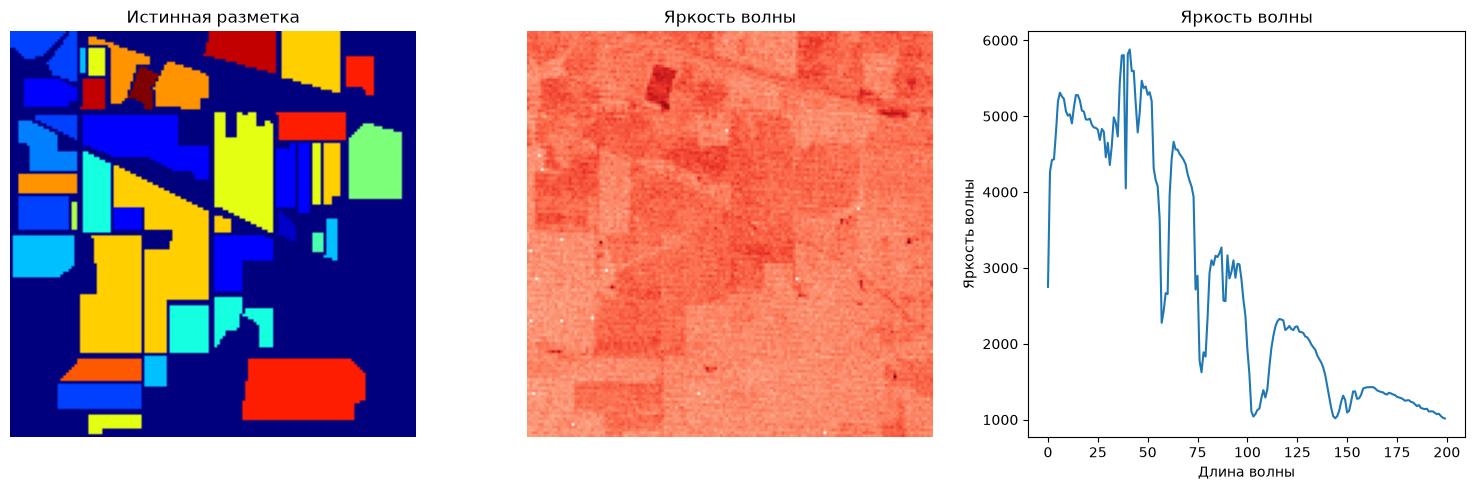

In [3]:
data = np.load('indianpinearray.npy')
ground_truth = np.load('IPgt.npy')

h, w, bands = data.shape
ratio = 1

finish = int(np.sqrt(h*w*ratio))
data = data[:finish,:finish,:]
gt = ground_truth[:finish,:finish]

X = data.reshape(-1, bands)
y = gt.reshape(-1)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Первый график: истинная разметка
axs[0].imshow(ground_truth, cmap='jet')
axs[0].set_title('Истинная разметка')
axs[0].axis('off')

# Второй график: яркость выбранной волны
axs[1].imshow(data[:, :, 1], cmap='Reds')
axs[1].set_title('Яркость волны')
axs[1].axis('off')

# Третий график: волны для произвольной точки
axs[2].plot(data[1, 2, :])
axs[2].set_title('Яркость волны')
axs[2].set_xlabel('Длина волны')
axs[2].set_ylabel('Яркость волны')

plt.tight_layout()
plt.show()

Точность на тестовой выборке: 0.547717184527584


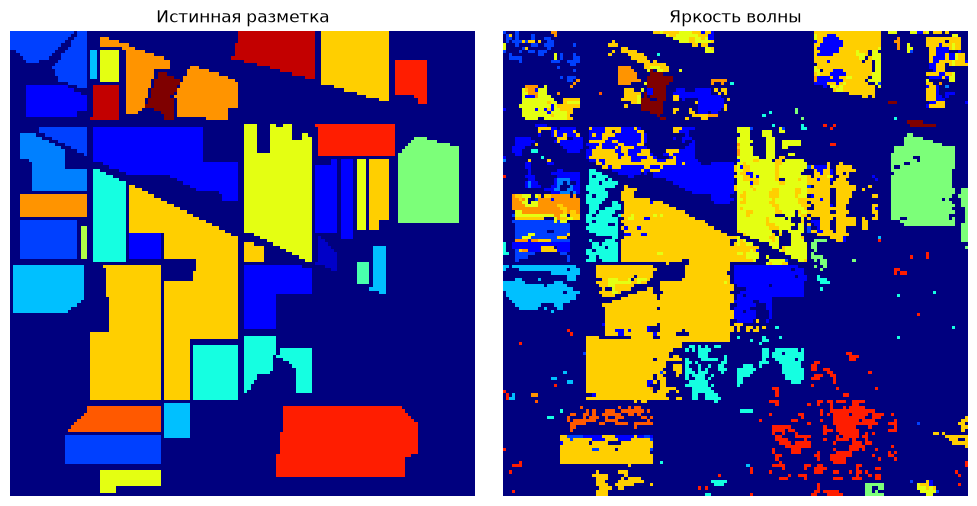

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=42, stratify=y)

k = 30

#pca = KernelPCA(kernel = 'linear', n_components = k)
pca = PCA(n_components = k)

X_train_ = pca.fit_transform(X_train)
X_test_ = pca.fit_transform(X_test)

svm = SVC(kernel = 'rbf', degree = 10, gamma = 'scale')
svm = svm.fit(X_train_, y_train)
test_score = svm.score(X_test_, y_test)

print("Точность на тестовой выборке:", test_score)

predicted = svm.predict(pca.fit_transform(X))

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Первый график: истинная разметка
axs[0].imshow(ground_truth, cmap='jet')
axs[0].set_title('Истинная разметка')
axs[0].axis('off')

# Второй график: яркость выбранной волны
axs[1].imshow(predicted.reshape((finish,finish)), cmap='jet')
axs[1].set_title('Яркость волны')
axs[1].axis('off')

plt.tight_layout()
plt.show()